In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


mu_s = 1.3271244e11    # sun gravitational parameter (km^3/s^2)
mu_e = 398600.4415     # earth gravitational parameter (km^3/s^2)
mu_m = 4902.8          # moon gravitational parameter (km^3/s^2)
R_e  = 6378.14         # earth radius (km)
R_m  = 1737.4          # moon radius (km)
d_e_m  = 384400        # earth-moon distance (km)
moon_SOI = 66200       # moon sphere of influence (km)

In [3]:
# COE from SV Function
def rv_2_coe(R, V, mu):

    eps = 1e-12

    R = np.array(R)
    V = np.array(V)

    r = np.linalg.norm(R)
    v = np.linalg.norm(V)

    vr = np.dot(R, V) / r

    H = np.cross(R, V)
    h = np.linalg.norm(H)

    incl = np.arccos(H[2] / h)

    N = np.cross([0, 0, 1], H)
    n = np.linalg.norm(N)

    if n != 0:
        RA = np.arccos(N[0] / n)
        if N[1] < 0:
            RA = 2 * np.pi - RA
    else:
        RA = 0

    E = 1 / mu * ((v**2 - mu / r) * R - r * vr * V)
    e = np.linalg.norm(E)

    if n != 0 and e > eps:
        w = np.arccos(np.dot(N, E) / n / e)
        if E[2] < 0:
            w = 2 * np.pi - w
    else:
        w = 0

    if e > eps:
        if np.dot(E, R) / e / r > 1 and np.dot(E, R) / e / r < 1.00000001:
            TA = 0.0
        else:
            TA = np.arccos(np.dot(E, R) / e / r)
        if vr < 0:
            TA = 2 * np.pi - TA
    else:
        cp = np.cross(N, R)
        if cp[2] >= 0:
            TA = np.arccos(np.dot(N, R) / n / r)
        else:
            TA = 2 * np.pi - np.arccos(np.dot(N, R) / n / r)

    a = h**2 / mu / (1 - e**2)


    return a, h, e, np.rad2deg(incl), np.rad2deg(RA), np.rad2deg(w), np.rad2deg(TA)



#Trasformation Function
def coe_2_rv(a, e, RAAN, i, w, mu, TA):  

    i = np.radians(i)
    w = np.radians(w)
    RAAN = np.radians(RAAN)
    TA = np.radians(TA)
       
    r_perifocal = a * (1 - e**2) / (1 + e * np.cos(TA)) * np.array([np.cos(TA), np.sin(TA), 0])
    v_perifocal = mu / np.sqrt(mu * a * (1 - e**2)) * np.array([-np.sin(TA), e + np.cos(TA), 0])
    
    R_z_RA = np.array([[np.cos(RAAN), -np.sin(RAAN), 0],
                       [np.sin(RAAN), np.cos(RAAN), 0],
                       [0, 0, 1]])
    
    R_x_incl = np.array([[1, 0, 0],
                         [0, np.cos(i), -np.sin(i)],
                         [0, np.sin(i), np.cos(i)]])
    
    R_z_w = np.array([[np.cos(w), -np.sin(w), 0],
                      [np.sin(w), np.cos(w), 0],
                      [0, 0, 1]])

    Q = np.dot(R_z_RA, np.dot(R_x_incl, R_z_w))

    r = np.dot(Q, r_perifocal)
    v = np.dot(Q, v_perifocal)

    return r, v



#Trasformation Function
def rtn_to_eci(vec_rtn, r_eci, v_eci):

    n = np.cross(r_eci, v_eci)

    R = r_eci / np.linalg.norm(r_eci)
    N = n / np.linalg.norm(n)

    T = np.cross(N, R)

    Q = np.column_stack((R, T, N))

    return np.dot(Q, vec_rtn)



def rotate2d(v, delta_rad):
    """Rotate 2D vector v by angle delta_rad (radians), CCW."""
    c, s = np.cos(delta_rad), np.sin(delta_rad)
    R = np.array([[c, -s],
                  [s,  c]])
    v = np.asarray(v, dtype=float).reshape(2,)
    return R @ v


def coe_from_r_vr_vt(r, v_r, v_t, mu):
    h = r * v_t
    v2 = v_r**2 + v_t**2
    eps = 0.5*v2 - mu/r

    a = -mu/(2*eps)
    p = h**2 / mu
    e = np.sqrt(1 + (2*eps*h**2)/(mu**2))

    cos_TA = (p/r - 1)/e
    sin_TA = (v_r*h)/(mu*e)
    TA = np.arctan2(sin_TA, cos_TA) 

    return a, e, p, h, np.rad2deg(TA)

In [4]:
a_s = R_e + 220
e_s = 0
i_s = 0
RAAN_s = 0
w_s = 0
TA_s = 0

a_m = d_e_m
e_m = 0
i_m = 0
RAAN_m = 0
w_m = 0
TA_m = 0

In [11]:
# Define Apogees Range
apogees_range = np.arange(1.1*d_e_m, 1.41*d_e_m, 0.01*d_e_m)


# Create Lists
TA_intercept = []
v_r_intercept = []
v_t_intercept = []
t_intercept = []
perilune_alt = []


# Earth Parking Orbit
perigee_transfer = R_e + 220


# Moon Velocity in Circular Orbit
v_moon = np.sqrt(mu_e / d_e_m)


# Loop over the Apogees
for apogee_transfer in apogees_range:

   # Orbital Elements of Translunar Injection
   a_transfer = 0.5*(apogee_transfer + perigee_transfer)
   e_transfer = (apogee_transfer - perigee_transfer) / (apogee_transfer + perigee_transfer)
   h_transfer = np.sqrt(a_transfer * mu_e * (1 - e_transfer**2))


   # True anomaly of Interseption
   cos_TA = (h_transfer**2 / (d_e_m) / mu_e - 1) / e_transfer
   TA = np.arccos(cos_TA)


   # Radial and Transverse velocities at Interseption
   v_r = mu_e / h_transfer * e_transfer * np.sin(TA)
   v_t = mu_e / h_transfer * (1 + e_transfer * np.cos(TA))

   print(a_transfer, mu_e / h_transfer, e_transfer, np.rad2deg(TA), v_r, v_t, h_transfer/d_e_m)


   # Transfer Time at Interseption
   E = 2 * np.arctan(np.sqrt((1-e_transfer)/(1+e_transfer)) * np.tan(TA/2))
   M = E - e_transfer * np.sin(E)
   t = M * h_transfer**3 / mu_e**2 / (1-e_transfer**2)**1.5


   # Relative Velocity in the Moon frame
   v_rel = [v_r, v_t - v_moon]
   v_inf = np.linalg.norm(v_rel)


   # Velocity Rotation during the Flyby
   delta = 2 * np.arctan2(v_r, (v_t - v_moon))


   # Hyperbolic parameters of Lunar Flyby
   a_flyby = mu_m / v_inf**2
   e_flyby = 1 / np.sin(delta/2)
   perilune_flyby = a_flyby * (e_flyby - 1)


   # Radial and Transverse Velocities after Flyby
   v_rel_out = rotate2d(v_rel, delta)
   v_r_out = v_rel_out[0]
   v_t_out = v_rel_out[1] + v_moon


   # Save Parameters for t=3 days
   if t >= 3*86400:
      a_s = a_transfer
      e_s = e_transfer
      TA_s = np.rad2deg(TA)
      apogee = apogee_transfer
      perilune = perilune_flyby - R_m
      t_trans = t

      # Orbital Parameters of Free Return Trajectory
      coe = coe_from_r_vr_vt(d_e_m, v_r_out, v_t_out, mu_e)
      w_out = np.rad2deg(TA) - (coe[4] + 360)


   # Fill lists for plots
   TA_intercept.append(np.rad2deg(TA))
   v_r_intercept.append(v_r)
   v_t_intercept.append(v_t)
   t_intercept.append(t/86400)
   perilune_alt.append(perilune_flyby - R_m)

214719.07000000004 5.53866886582913 0.9692708244311974 175.43642366309814 0.42714363120399085 0.18721860079507635 0.1872186007950766
216641.07000000004 5.538285522094629 0.9695434480636566 175.23551637525728 0.446000340868355 0.18723155951259154 0.18723155951259135
218563.07000000004 5.537908997954785 0.9698112769005303 175.04615638838396 0.4637794230314827 0.18724428944403715 0.18724428944403715
220485.07000000004 5.537539113032993 0.9700744363325825 174.86697721896252 0.4806083665000732 0.1872567965953085 0.1872567965953084
222407.07000000004 5.537175693258343 0.9703330474161634 174.69686432156163 0.4965911408858795 0.18726908676390525 0.18726908676390522
224329.07000000004 5.536818570592514 0.9705872270588916 174.53489377605 0.5118139226572274 0.18728116554789295 0.18728116554789276
226251.07000000004 5.536467582770621 0.9708370881958701 174.3802890137159 0.5263491361483553 0.18729303835440617 0.18729303835440603
228173.07000000004 5.536122573055398 0.9710827399569983 174.2323894774

In [6]:
print("\n" + "="*78)
print("CASE OF A ~3 DAYS TRANSFER")
print("="*78)

print("\n[1] Translunar Injection (Earth-centered ellipse)")
print(f"  apogee_transfer (ra/rm)   = {apogee/d_e_m:.6g}")
print(f"  time_transfer (days)      = {t_trans/86400:.6g}")
print(f"  a_transfer                = {a_s:.6g} km")
print(f"  e_transfer                = {e_s:.4f} km")
print(f"  TA_intercept              = {TA_s:.1f} deg")

print("\n[2] Lunar Flyby (Moon-centered hyperbola)")
print(f"  perilune altitude         = {perilune:.4g} km")

print("\n[3] Free Return (Earth-centered, computed from coe)")
print(f"  a_free_return              = {coe[0]:.6g} km")
print(f"  e_free_return              = {coe[1]:.4f}")
print(f"  w_free_return              = {w_out:.4f}")
print(f"  TA_free_return             = {coe[4]+360:.1f} deg")

print("="*78 + "\n")


CASE OF A ~3 DAYS TRANSFER

[1] Translunar Injection (Earth-centered ellipse)
  apogee_transfer (ra/rm)   = 1.33
  time_transfer (days)      = 3.00894
  a_transfer                = 258925 km
  e_transfer                = 0.9745 km
  TA_intercept              = 172.5 deg

[2] Lunar Flyby (Moon-centered hyperbola)
  perilune altitude         = 502.8 km

[3] Free Return (Earth-centered, computed from coe)
  a_free_return              = 258925 km
  e_free_return              = 0.9745
  w_free_return              = -15.0649
  TA_free_return             = 187.5 deg



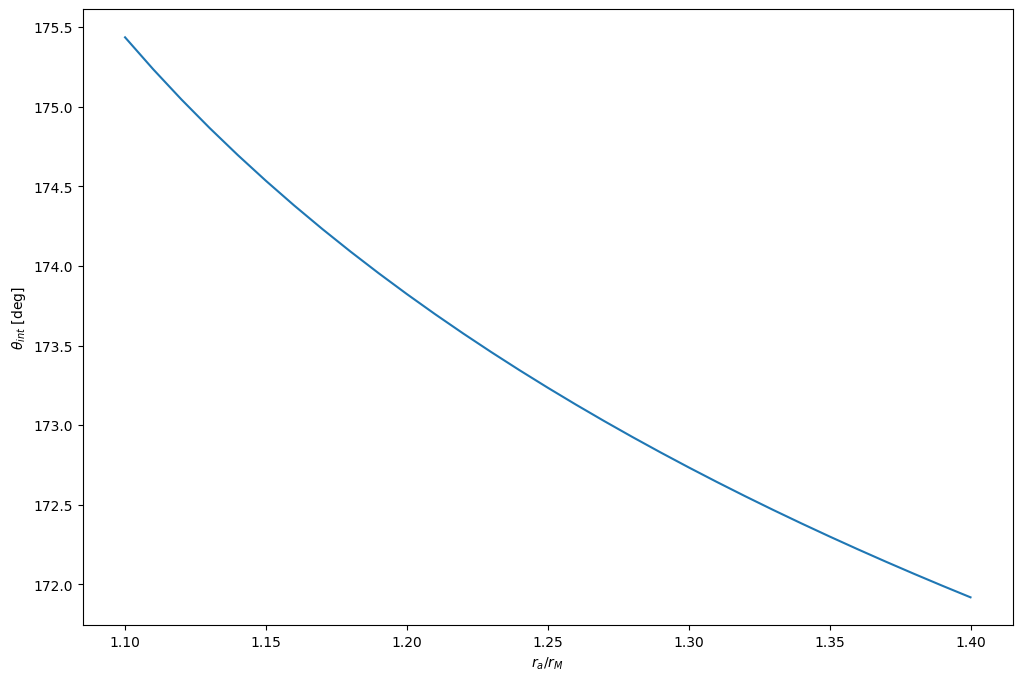

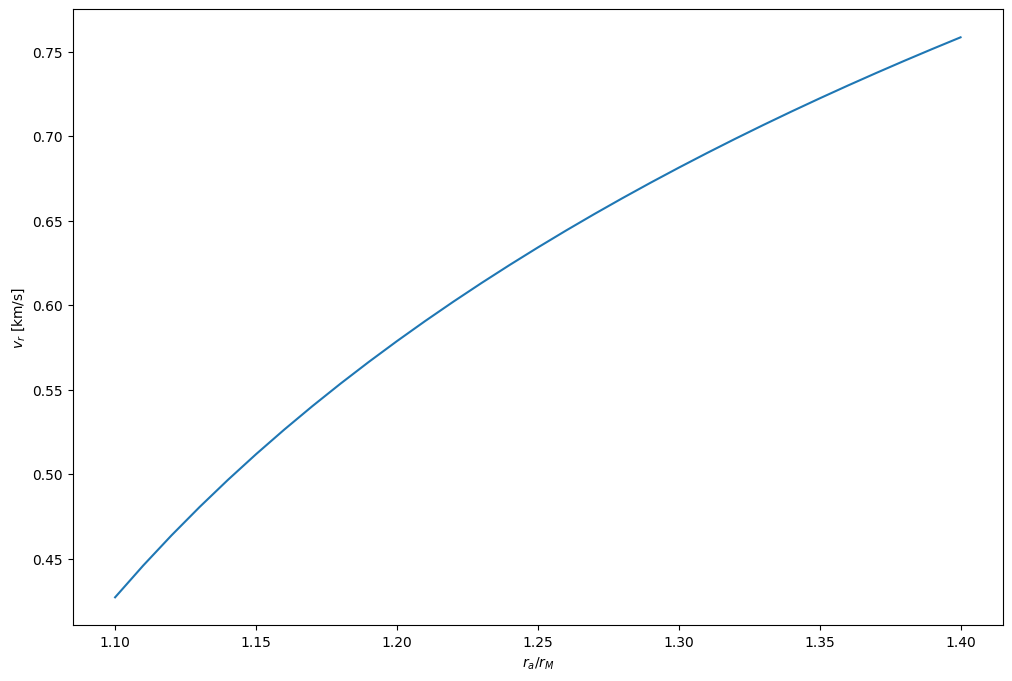

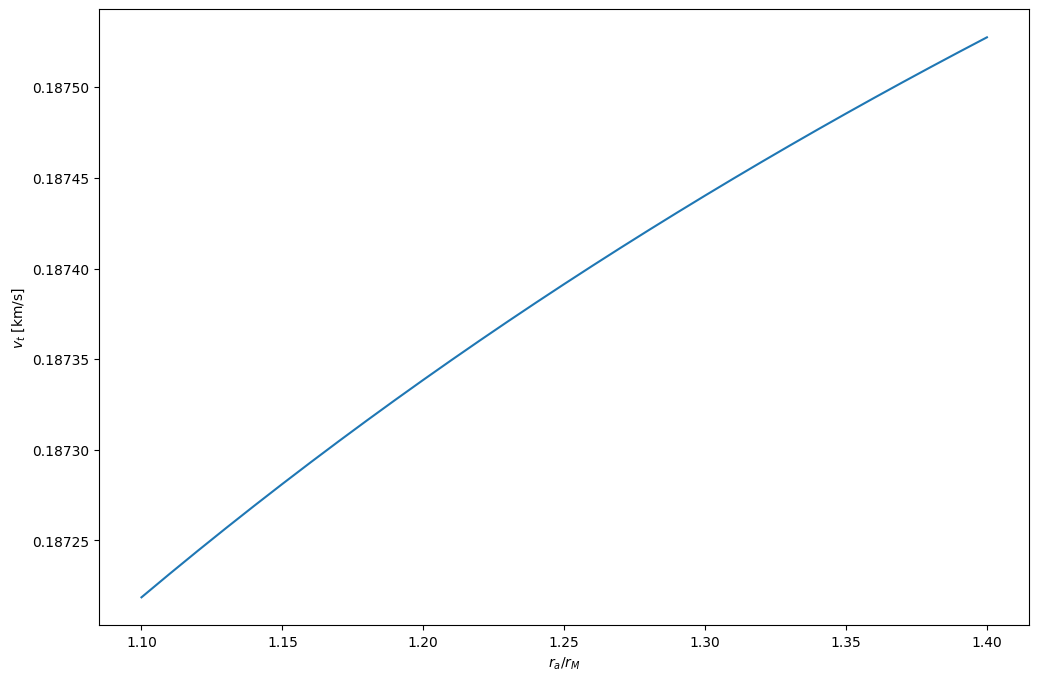

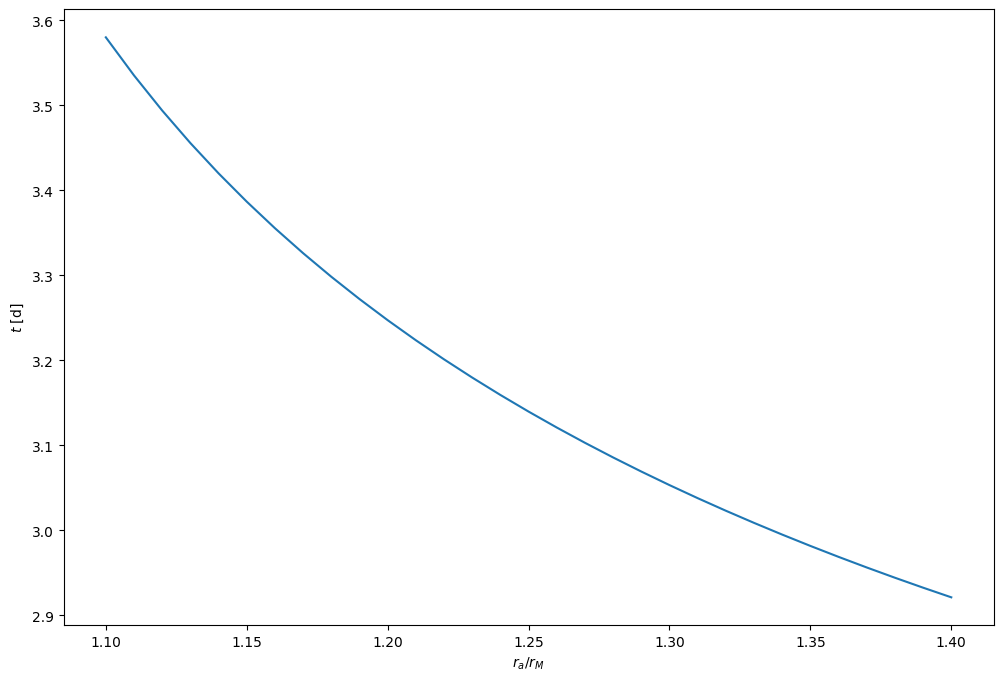

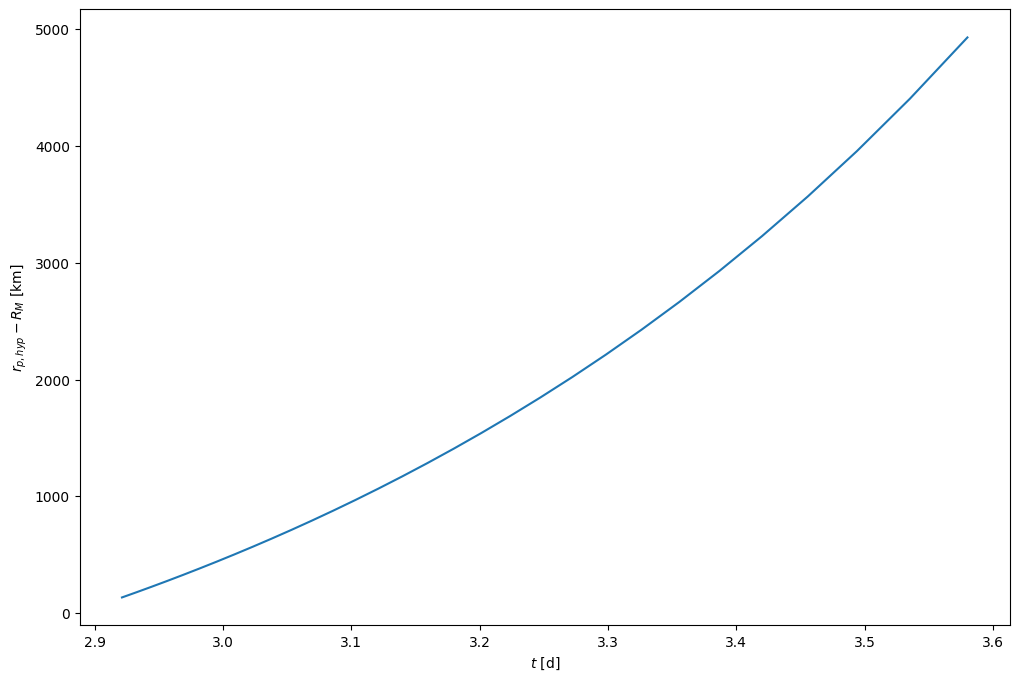

In [7]:
plt.figure(figsize=(12, 8))
plt.plot(apogees_range / d_e_m, TA_intercept)
plt.xlabel(r"$r_a / r_M$")
plt.ylabel(r"$\theta_{int}$ [deg]")
#plt.grid(True)

plt.figure(figsize=(12, 8))
plt.plot(apogees_range / d_e_m, v_r_intercept)
plt.xlabel(r"$r_a / r_M$")
plt.ylabel(r"$v_r$ [km/s]")
#plt.grid(True)

plt.figure(figsize=(12, 8))
plt.plot(apogees_range / d_e_m, v_t_intercept)
plt.xlabel(r"$r_a / r_M$")
plt.ylabel(r"$v_t$ [km/s]")
#plt.grid(True)

plt.figure(figsize=(12, 8))
plt.plot(apogees_range / d_e_m, t_intercept)
plt.xlabel(r"$r_a / r_M$")
plt.ylabel(r"$t$ [d]")
#plt.grid(True)

plt.figure(figsize=(12, 8))
plt.plot(t_intercept, perilune_alt)
plt.xlabel(r"$t$ [d]")
plt.ylabel(r"$r_{p,hyp} - R_M$ [km]")
#plt.grid(True)

plt.show()

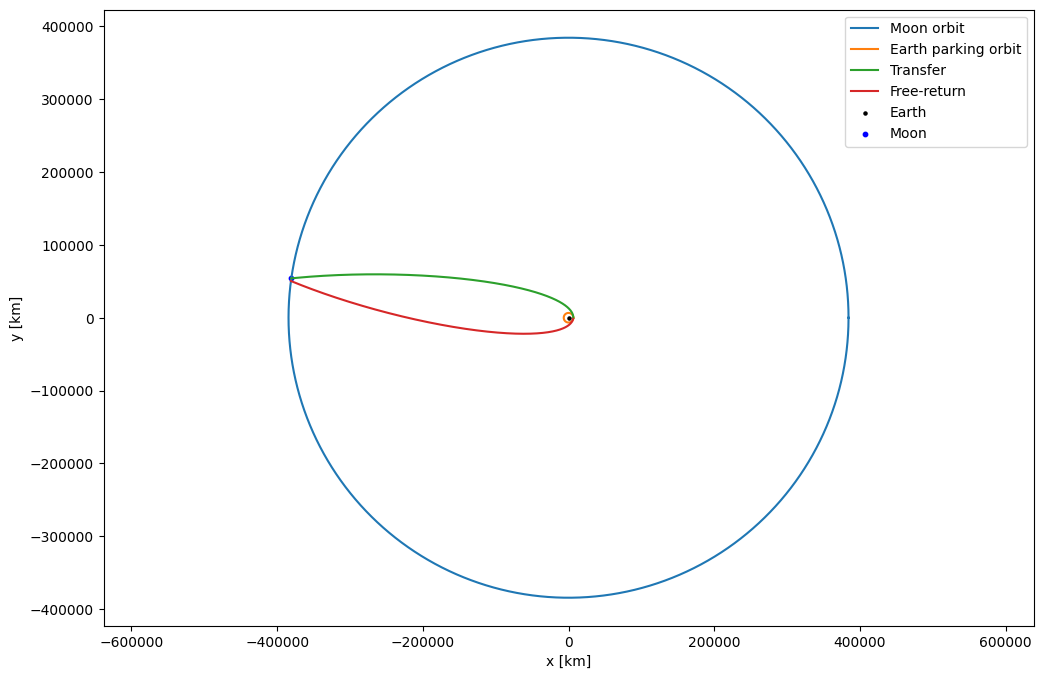

In [8]:

N = 2000
TA_transfer = np.linspace(0.0, TA_intercept[-1], N)        # from perigee to intercept
TA_free_return = np.linspace(coe[4]+360, 360, N)           # from intercept back to perigee direction

theta = np.linspace(0.0, 2*np.pi, N)

# Earth parking orbit (circle)
r_parking = perigee_transfer
x_parking = r_parking * np.cos(theta)
y_parking = r_parking * np.sin(theta)

# Moon orbit (circle)
x_moon = d_e_m * np.cos(theta)
y_moon = d_e_m * np.sin(theta)


# Transfer orbit positions (use your coe_2_rv, planar: i=raan=w=0)
x_tr, y_tr = [], []
for TA in TA_transfer:
    r_vec, _ = coe_2_rv(a_transfer, e_transfer, 0, 0, 0, mu_e, TA)
    x_tr.append(r_vec[0])
    y_tr.append(r_vec[1])


# Free-return orbit positions (same plane and orientation in your setup)
x_fr, y_fr = [], []
for TA in TA_free_return:
    r_vec, _ = coe_2_rv(coe[0], coe[1], 0, 0, w_out, mu_e, TA)
    x_fr.append(r_vec[0])
    y_fr.append(r_vec[1])


plt.figure(figsize=(12, 8))
plt.axis("equal")

plt.plot(x_moon, y_moon, label="Moon orbit")
plt.plot(x_parking, y_parking, label="Earth parking orbit")
plt.plot(x_tr, y_tr, label="Transfer")
plt.plot(x_fr, y_fr, label="Free-return")

# Mark key points
plt.scatter([0], [0], s=5, color='black', label="Earth")
plt.scatter(x_tr[-1], y_tr[-1], s=10, zorder=-1, color='b', label="Moon")

plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.legend()
plt.show()
